In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

from sklearn.model_selection import train_test_split,cross_val_score

In [36]:
def load_placement_data(file_path):
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f'The desired dataset was not found in the location passed .')
    except Exception as e:
        print(f'Unable to fetch the dataset : {e}')
    return df

In [37]:
df = load_placement_data('Job_Placement_Data_Enhanced.csv')

In [39]:
df.shape

(215, 20)

In [40]:
df.columns # We have a lot of columns to choose and the status column is to predicted judging from the dataset 

Index(['gender', 'ssc_percentage', 'ssc_board', 'hsc_percentage', 'hsc_board',
       'hsc_subject', 'degree_percentage', 'undergrad_degree',
       'work_experience', 'emp_test_percentage', 'specialisation',
       'mba_percent', 'status', 'years_experience', 'skills_match_percent',
       'num_certifications', 'internship_completed', 'interview_score',
       'company_tier', 'job_competition_level'],
      dtype='object')

In [41]:
df.head()

,gender,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_subject,degree_percentage,undergrad_degree,work_experience,emp_test_percentage,specialisation,mba_percent,status,years_experience,skills_match_percent,num_certifications,internship_completed,interview_score,company_tier,job_competition_level
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,3,98,1,0,94,Mid,Medium
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,4,88,1,1,54,MNC,Low
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,2,41,1,1,82,Startup,Low
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,4,41,0,0,50,MNC,High
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,4,67,0,0,67,Mid,High


In [ ]:
df.nunique()

gender                     2
ssc_percentage           103
ssc_board                  2
hsc_percentage            97
hsc_board                  2
hsc_subject                3
degree_percentage         89
undergrad_degree           3
work_experience            2
emp_test_percentage      100
specialisation             2
mba_percent              205
status                     2
years_experience           6
skills_match_percent      56
num_certifications         6
internship_completed       2
interview_score           50
company_tier               3
job_competition_level      3
dtype: int64

In [ ]:
df.info() # No null values 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 215 non-null    object 
 1   ssc_percentage         215 non-null    float64
 2   ssc_board              215 non-null    object 
 3   hsc_percentage         215 non-null    float64
 4   hsc_board              215 non-null    object 
 5   hsc_subject            215 non-null    object 
 6   degree_percentage      215 non-null    float64
 7   undergrad_degree       215 non-null    object 
 8   work_experience        215 non-null    object 
 9   emp_test_percentage    215 non-null    float64
 10  specialisation         215 non-null    object 
 11  mba_percent            215 non-null    float64
 12  status                 215 non-null    object 
 13  years_experience       215 non-null    int64  
 14  skills_match_percent   215 non-null    int64  
 15  num_ce

In [46]:
df.select_dtypes(include='number')

,ssc_percentage,hsc_percentage,degree_percentage,emp_test_percentage,mba_percent,years_experience,skills_match_percent,num_certifications,internship_completed,interview_score
0,67.00,91.00,58.00,55.0,58.80,3,98,1,0,94
1,79.33,78.33,77.48,86.5,66.28,4,88,1,1,54
2,65.00,68.00,64.00,75.0,57.80,2,41,1,1,82
3,56.00,52.00,52.00,66.0,59.43,4,41,0,0,50
4,85.80,73.60,73.30,96.8,55.50,4,67,0,0,67
...,...,...,...,...,...,...,...,...,...,...
210,80.60,82.00,77.60,91.0,74.49,2,86,0,1,67
211,58.00,60.00,72.00,74.0,53.62,0,61,5,1,96
212,67.00,67.00,73.00,59.0,69.72,4,62,4,1,85
213,74.00,66.00,58.00,70.0,60.23,0,41,2,1,96


In [47]:
df.select_dtypes('object')

,gender,ssc_board,hsc_board,hsc_subject,undergrad_degree,work_experience,specialisation,status,company_tier,job_competition_level
0,M,Others,Others,Commerce,Sci&Tech,No,Mkt&HR,Placed,Mid,Medium
1,M,Central,Others,Science,Sci&Tech,Yes,Mkt&Fin,Placed,MNC,Low
2,M,Central,Central,Arts,Comm&Mgmt,No,Mkt&Fin,Placed,Startup,Low
3,M,Central,Central,Science,Sci&Tech,No,Mkt&HR,Not Placed,MNC,High
4,M,Central,Central,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed,Mid,High
...,...,...,...,...,...,...,...,...,...,...
210,M,Others,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed,Mid,Medium
211,M,Others,Others,Science,Sci&Tech,No,Mkt&Fin,Placed,MNC,Medium
212,M,Others,Others,Commerce,Comm&Mgmt,Yes,Mkt&Fin,Placed,Mid,High
213,F,Others,Others,Commerce,Comm&Mgmt,No,Mkt&HR,Placed,Startup,Medium


In [53]:
df.select_dtypes('object').nunique() # I plan to use OrdinalEncoder for this , but not to jump to conclusion we will plot the data and visualize it perfectly first

gender                   2
ssc_board                2
hsc_board                2
hsc_subject              3
undergrad_degree         3
work_experience          2
specialisation           2
status                   2
company_tier             3
job_competition_level    3
dtype: int64

Column : ssc_percentage


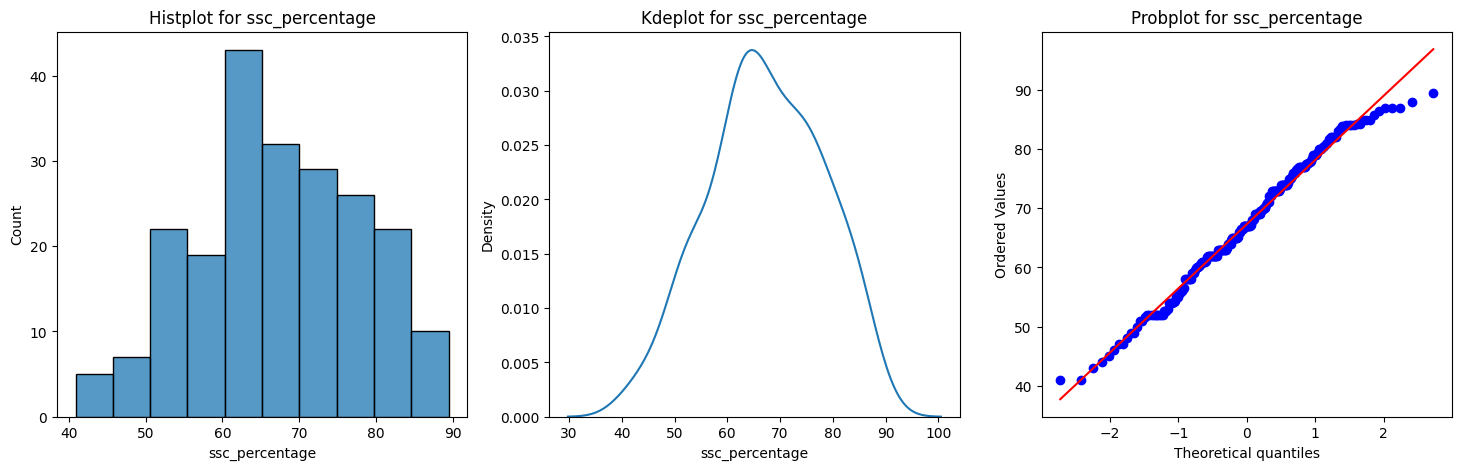

Column : hsc_percentage


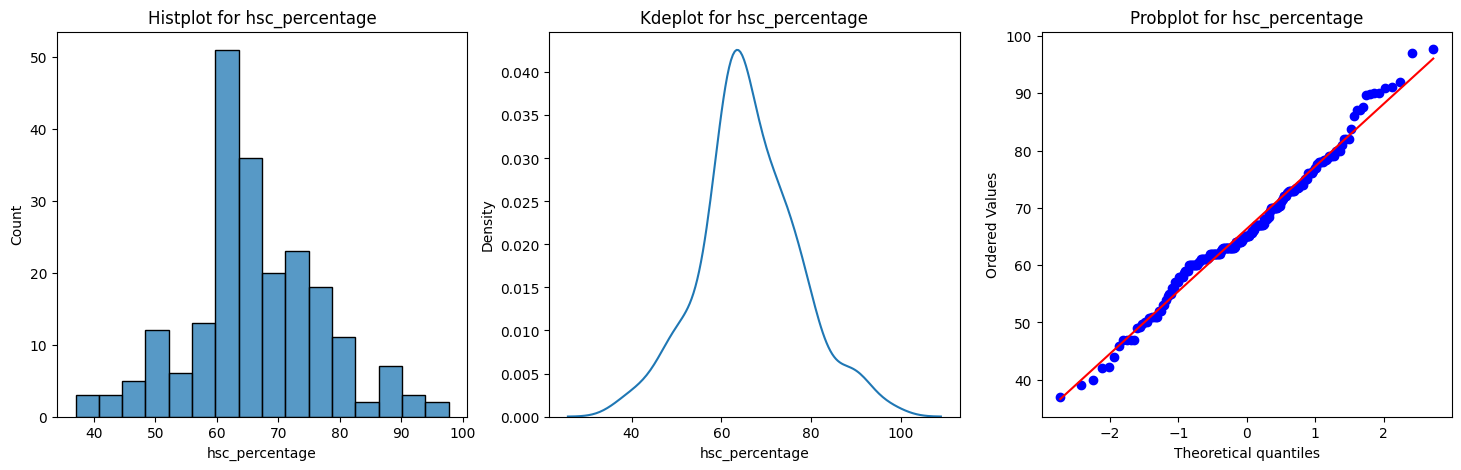

Column : degree_percentage


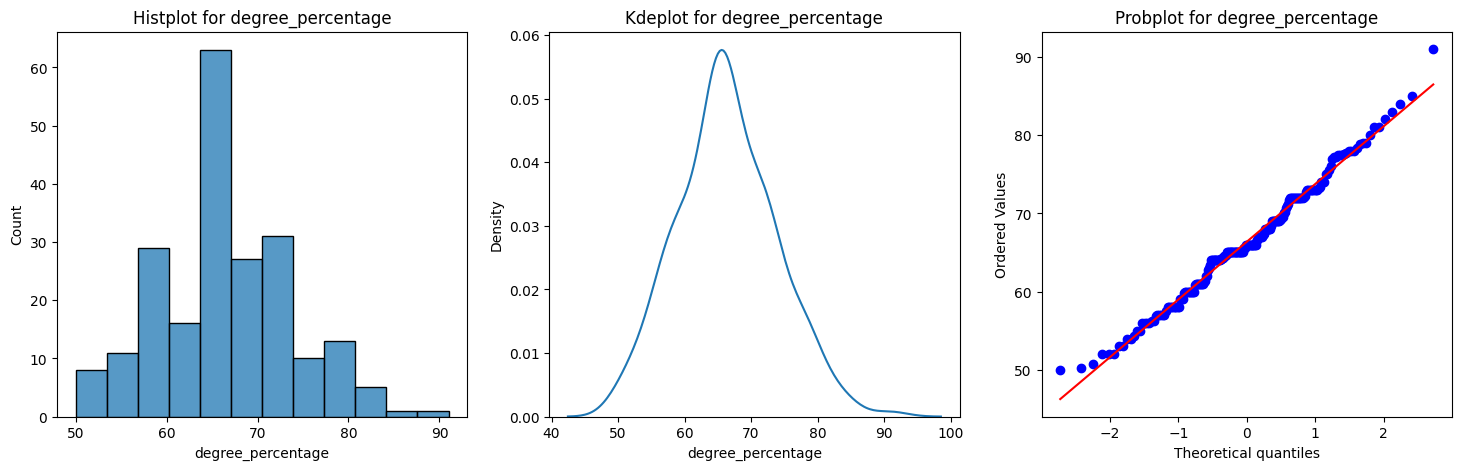

Column : emp_test_percentage


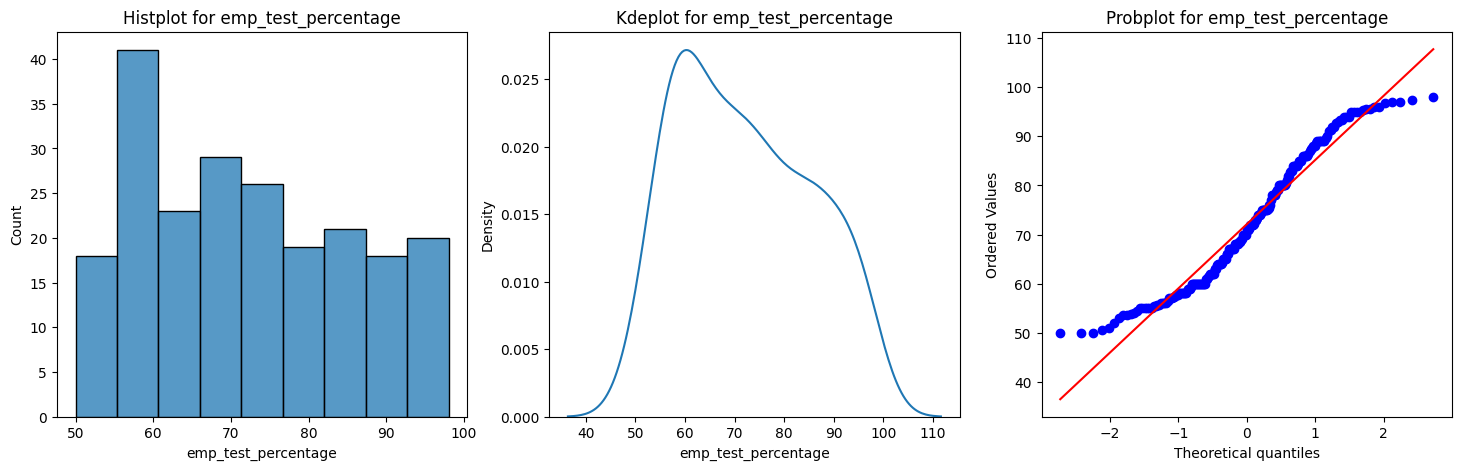

Column : mba_percent


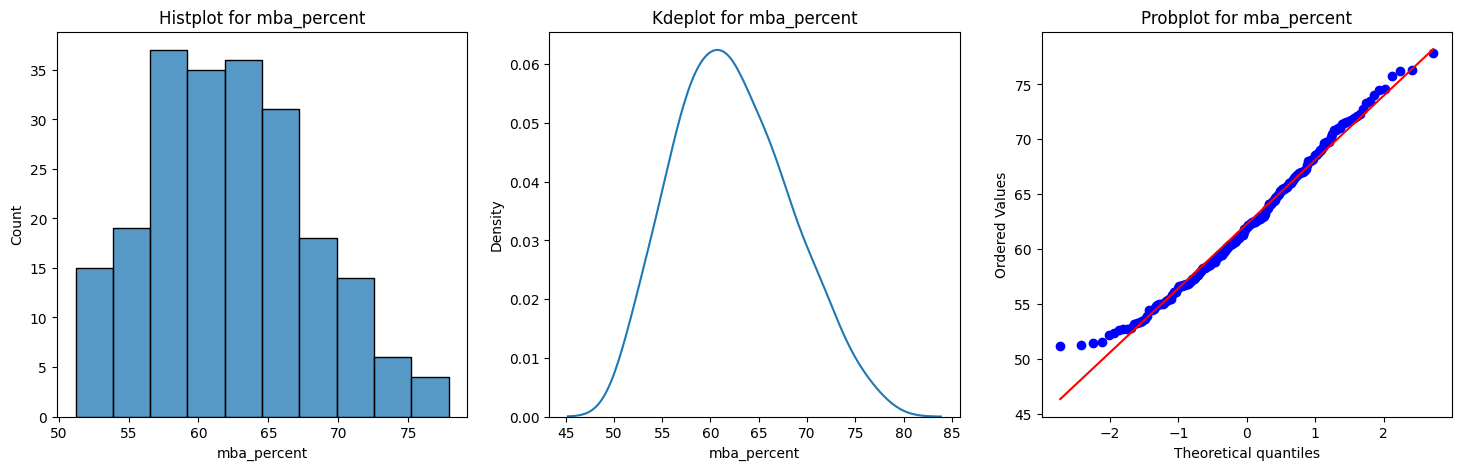

Column : years_experience


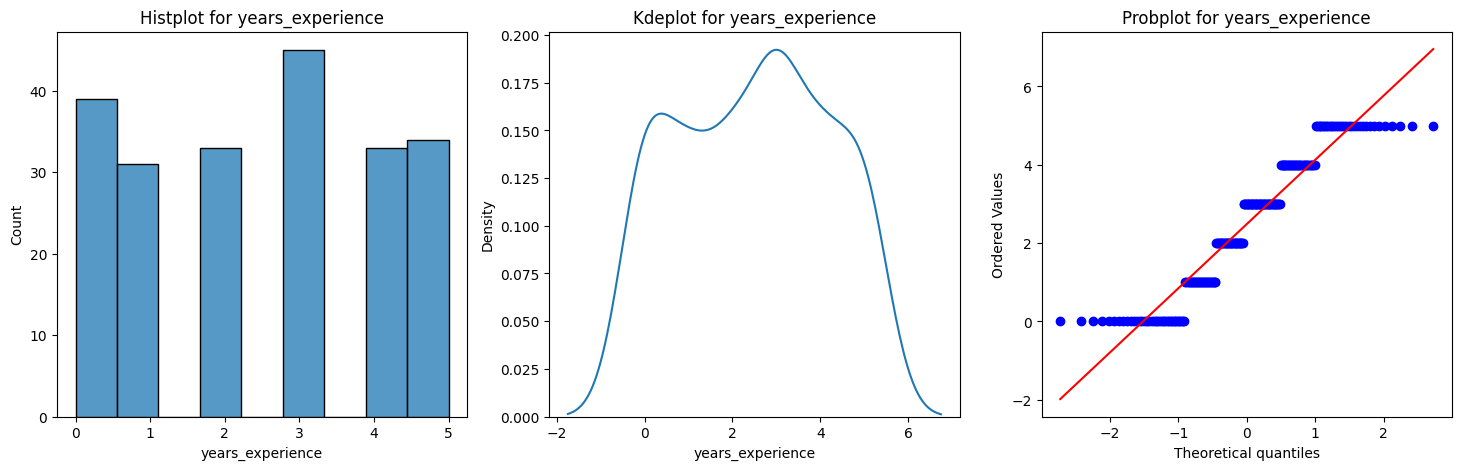

Column : skills_match_percent


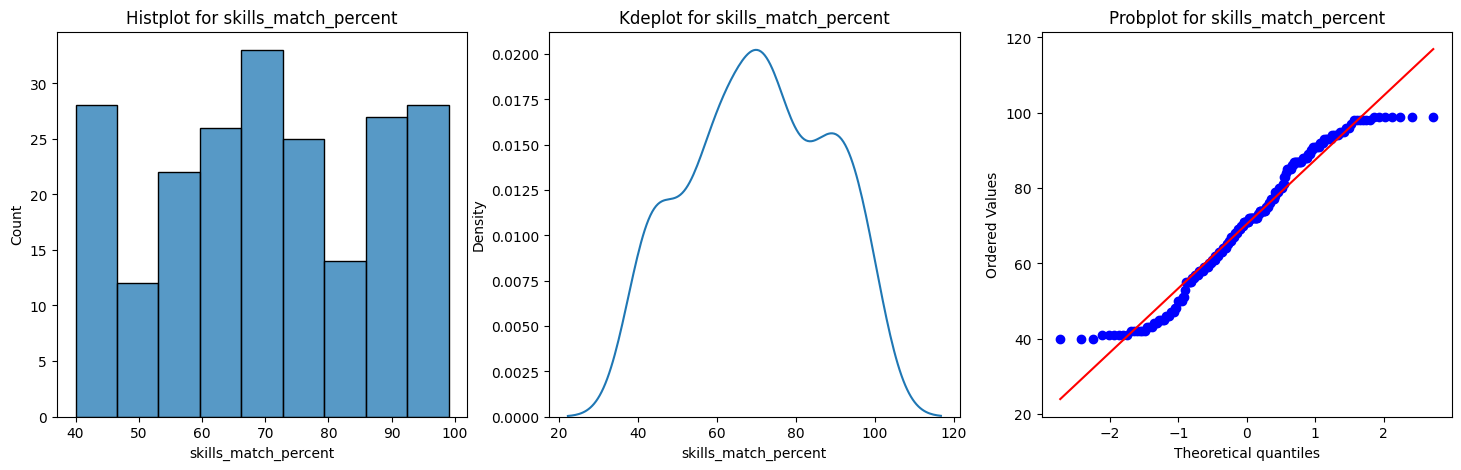

Column : num_certifications


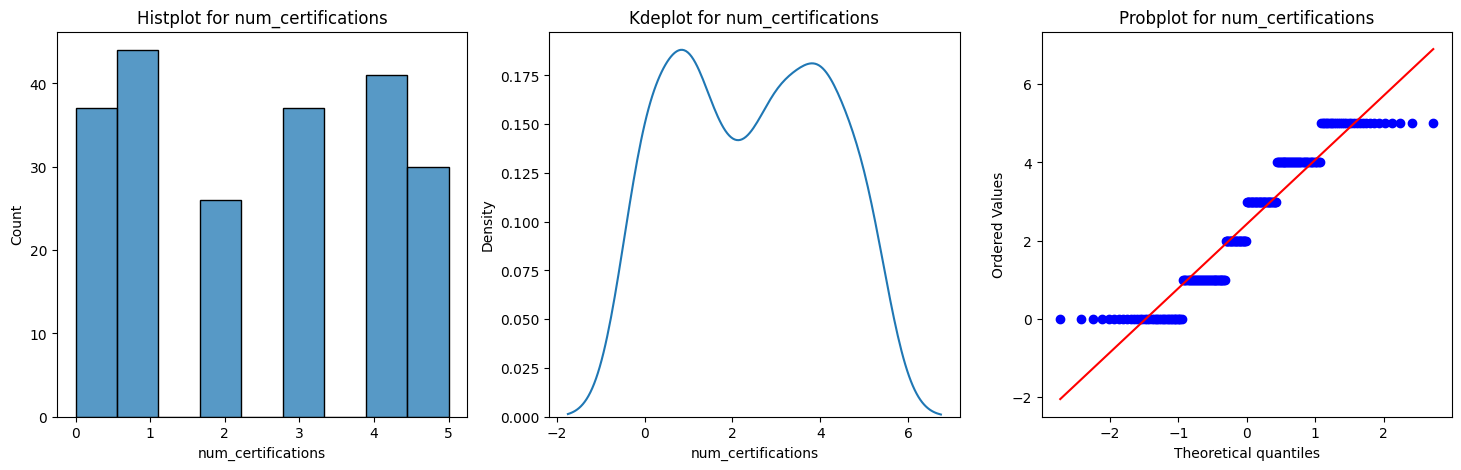

Column : internship_completed


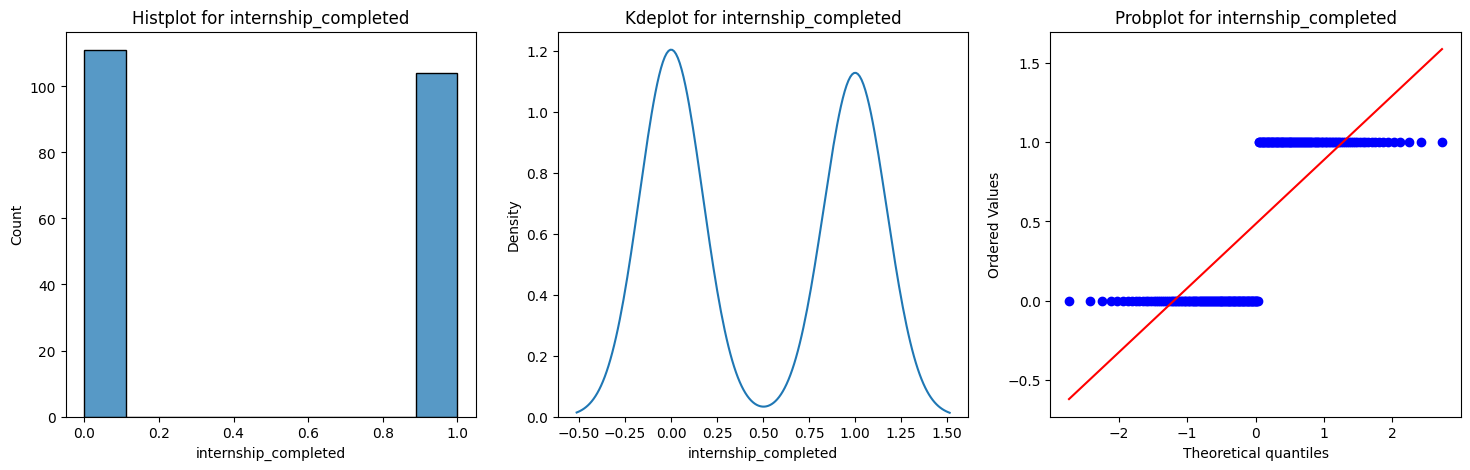

Column : interview_score


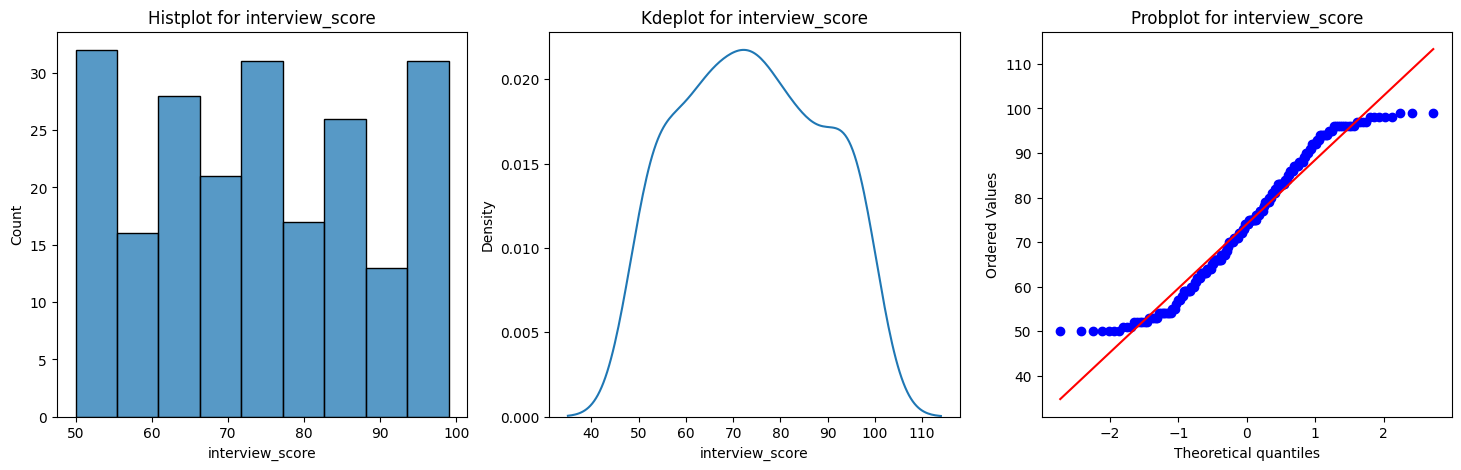

In [63]:
for x in df.select_dtypes(include='number').columns:

    print(f'Column : {x}')
    
    plt.figure(figsize=(18,5))

    plt.subplot(131)
    sns.histplot(data=df[x])
    plt.title(f'Histplot for {x}')

    plt.subplot(132)
    sns.kdeplot(data=df[x])
    plt.title(f'Kdeplot for {x}')

    plt.subplot(133)
    stats.probplot(df[x],plot=plt,dist='norm')
    plt.title(f'Probplot for {x}')

    plt.show()

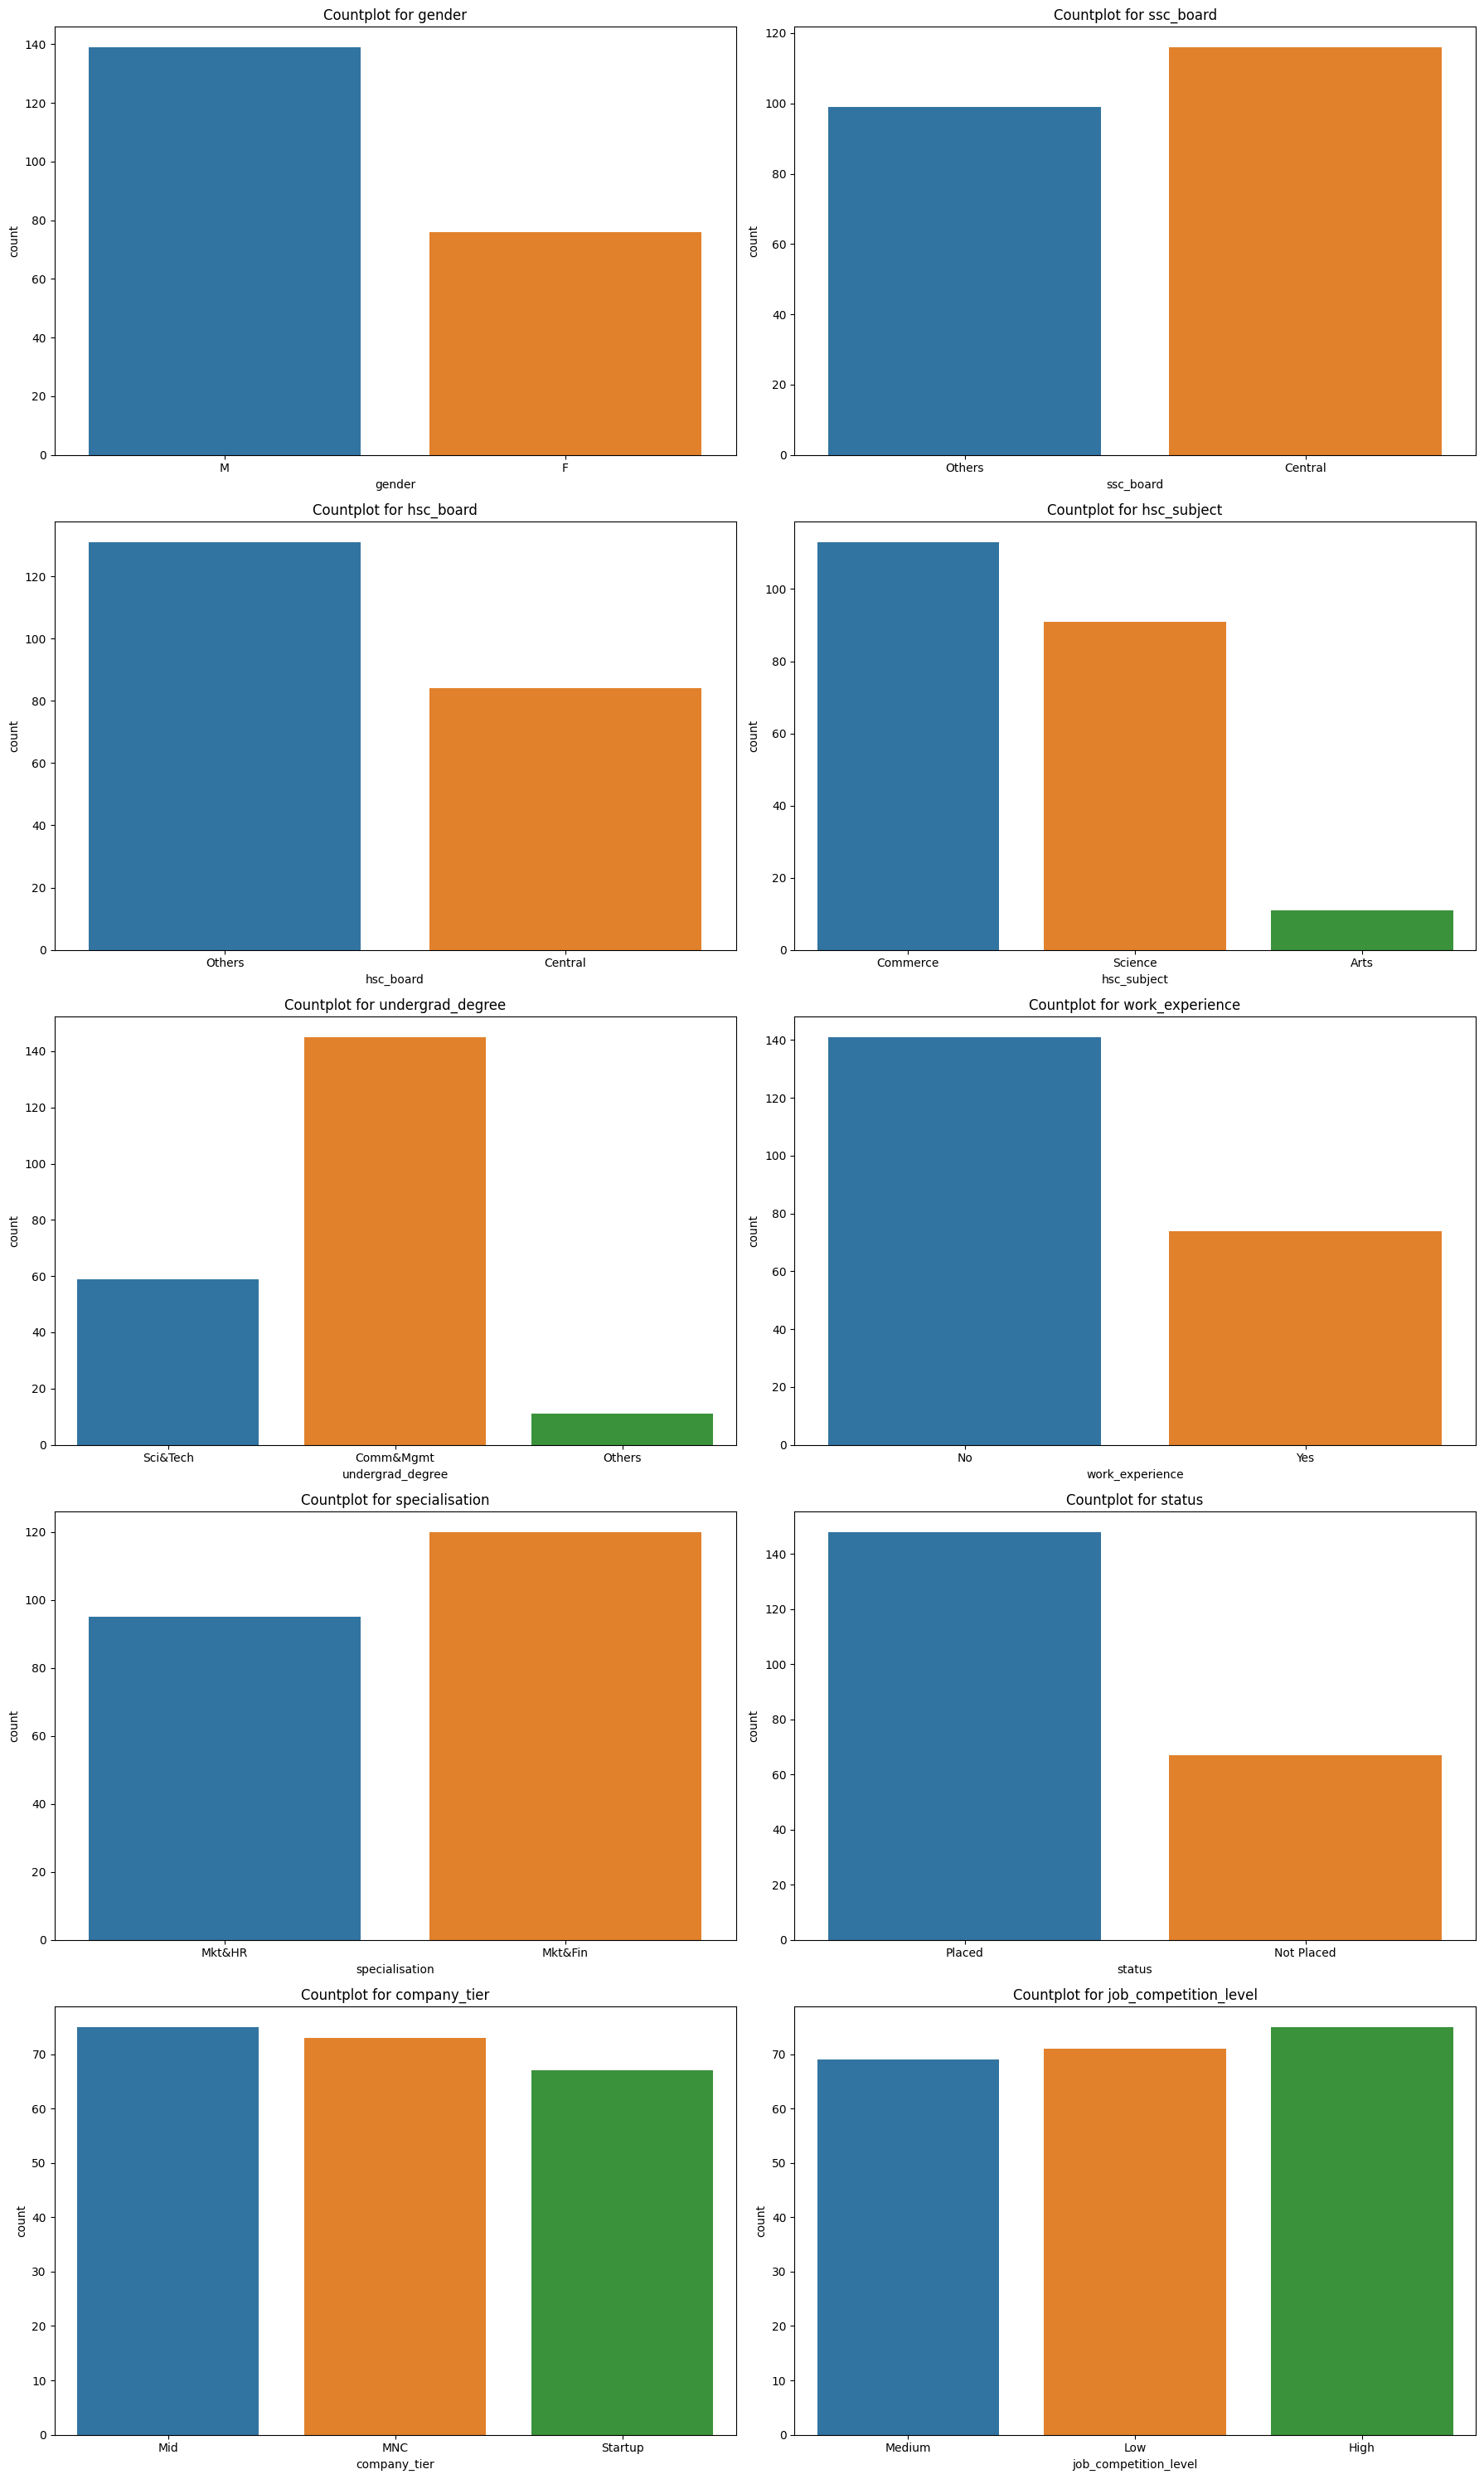

In [78]:

columns = df.select_dtypes(include='object').columns.to_list()

fig,axes = plt.subplots(nrows=5,ncols=2,figsize=(18,30))

axes = axes.flatten()

for index,column in enumerate(columns):
    
    sns.countplot(data=df,x=column,ax=axes[index],hue=column)
    axes[index].set_title(f'Countplot for {column}')

plt.tight_layout()
plt.show()